In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance


# 분류 : 통신사 Churn

In [430]:
orig_train_df = pd.read_csv("./data/real_world_data/churn_train.csv")
orig_test_df = pd.read_csv("./data/real_world_data/churn_test.csv")

df = orig_train_df.copy()
df.head()

,Customer_ID,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,Contract,AutoPay,Internet_Type,Has_Addon,NPS_Score,Region,Churn
0,22216,38,1,70096,449,1,0,Month-to-month,1,DSL,1,-57,Seoul,0
1,22583,33,11,38262,564,2,1,Month-to-month,0,Fiber,0,69,Seoul,1
2,21663,27,34,62086,362,1,0,Month-to-month,1,Fiber,1,21,Metro,1
3,23028,56,19,72615,595,0,0,1-year,0,DSL,0,16,Seoul,0
4,24344,31,62,63279,365,2,1,2-year,0,5G,0,13,Metro,0


In [431]:
df = orig_train_df.drop("Customer_ID", axis=1)
test_df = orig_test_df.drop("Customer_ID", axis=1)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 6400 non-null   int64
 1   Tenure_Months       6400 non-null   int64
 2   Monthly_Fee         6400 non-null   int64
 3   Total_Usage_GB      6400 non-null   int64
 4   Support_Tickets_3M  6400 non-null   int64
 5   Late_Payments_6M    6400 non-null   int64
 6   Contract            6400 non-null   str  
 7   AutoPay             6400 non-null   int64
 8   Internet_Type       6400 non-null   str  
 9   Has_Addon           6400 non-null   int64
 10  NPS_Score           6400 non-null   int64
 11  Region              6400 non-null   str  
 12  Churn               6400 non-null   int64
dtypes: int64(10), str(3)
memory usage: 650.1 KB


<Axes: ylabel='Frequency'>

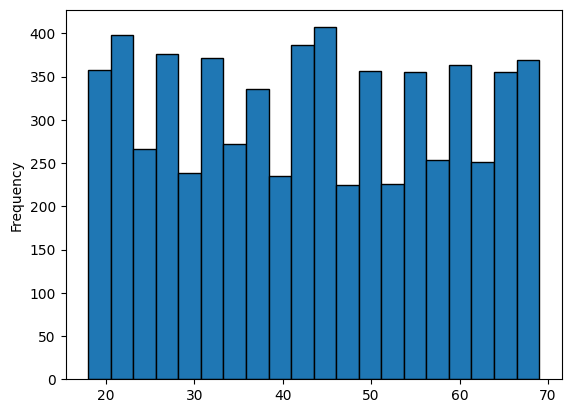

In [432]:
df["Age"].plot(kind="hist", bins=20, edgecolor="black")

<Axes: ylabel='Frequency'>

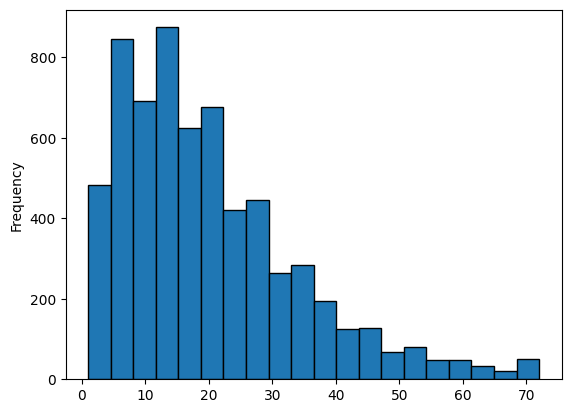

In [433]:
df["Tenure_Months"].plot(kind="hist", bins=20, edgecolor="black")

<Axes: ylabel='Frequency'>

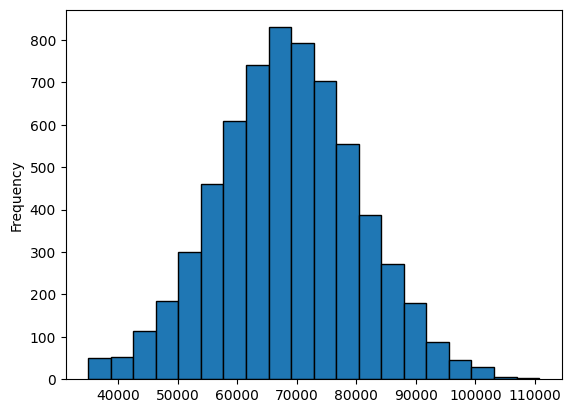

In [434]:
df["Monthly_Fee"].plot(kind="hist", bins=20, edgecolor="black")

<Axes: ylabel='Frequency'>

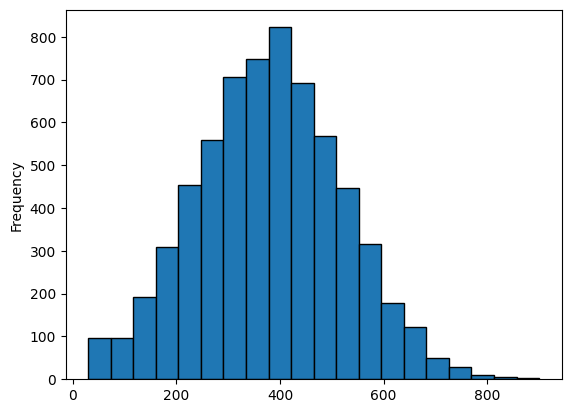

In [435]:
df["Total_Usage_GB"].plot(kind="hist", bins=20, edgecolor="black")

<Axes: ylabel='Frequency'>

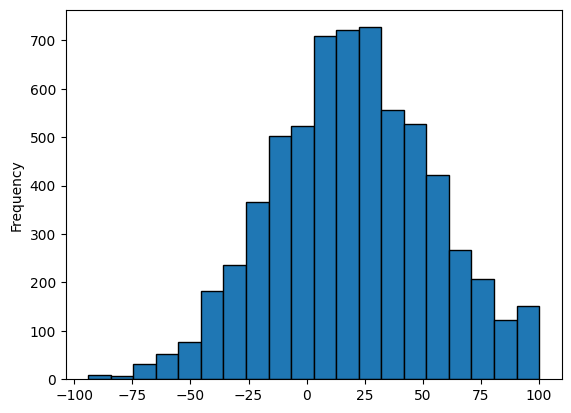

In [436]:
df["NPS_Score"].plot(kind="hist", bins=20, edgecolor="black")

In [437]:
df["Contract"].unique()

<StringArray>
['Month-to-month', '1-year', '2-year']
Length: 3, dtype: str

In [438]:
df["Contract"].value_counts()

Contract
Month-to-month    3493
1-year            1975
2-year             932
Name: count, dtype: int64

In [439]:
df.groupby("Contract")["Churn"].mean()

Contract
1-year            0.176203
2-year            0.114807
Month-to-month    0.345262
Name: Churn, dtype: float64

In [440]:
df.groupby("AutoPay")["Churn"].mean()

AutoPay
0    0.338930
1    0.195425
Name: Churn, dtype: float64

In [441]:
df.groupby("Support_Tickets_3M")["Churn"].mean()

Support_Tickets_3M
0    0.219780
1    0.263979
2    0.325000
3    0.374016
4    0.437500
5    0.333333
6    1.000000
Name: Churn, dtype: float64

In [442]:
df.groupby("Late_Payments_6M")["Churn"].mean()

Late_Payments_6M
0    0.212592
1    0.299902
2    0.415800
3    0.487805
4    0.571429
Name: Churn, dtype: float64

In [443]:
df.groupby("Internet_Type")["Churn"].mean()

Internet_Type
5G       0.274725
DSL      0.243298
Fiber    0.263576
Name: Churn, dtype: float64

In [444]:
df.groupby("Region")["Churn"].mean()

Region
Metro    0.259524
Other    0.261357
Seoul    0.258124
Name: Churn, dtype: float64

In [445]:
df["Churn"].mean()  # 상관이 없을 가능성이 높음.

## 데이터 불균형이 있다. (0이 1보다 많음) -> 하지만 실제 세상(test) 또한 0이 1보다 더 많다면(비율이 같다면)
## 그대로 학습한다.

np.float64(0.25953125)

In [446]:
## 데이터 불균형 확인
df["Churn"].value_counts()

Churn
0    4739
1    1661
Name: count, dtype: int64

In [447]:
# baseline 확인
df["Churn"].value_counts(normalize=True)

Churn
0    0.740469
1    0.259531
Name: proportion, dtype: float64

In [448]:

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["Region"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(contingency)

n = contingency.sum().sum()
k = min(contingency.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér’s V:", cramers_v)

# Region과 Internet_Type은 각각 churn와 직접적인 상관이 없을 수 있지만
# 다변량 문제에서는 변수가 다른 변수에 영향을 줄 수 있기 때문에 섣불리 제거하면 안된다.
# Internet_Type + Contract -> strong predictor

## Cramér’s V는 linear / marginal dependency만 측정.
## Tree model은 nonlinear + interaction 학습.

Cramér’s V: 0.0028484979487982467


In [ ]:
# Permutation Importance로 Predictor 파워가 없음을 확인하였고 Region, Internet_Type, Total_Usage_GB열을 제거해준다.
cols_to_drop = ["Region", "Internet_Type", "Total_Usage_GB"]

#df = df.drop(cols_to_drop, axis=1)
#test_df = test_df.drop(cols_to_drop, axis=1)

In [450]:
df.head()

,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,Contract,AutoPay,Internet_Type,Has_Addon,NPS_Score,Region,Churn
0,38,1,70096,449,1,0,Month-to-month,1,DSL,1,-57,Seoul,0
1,33,11,38262,564,2,1,Month-to-month,0,Fiber,0,69,Seoul,1
2,27,34,62086,362,1,0,Month-to-month,1,Fiber,1,21,Metro,1
3,56,19,72615,595,0,0,1-year,0,DSL,0,16,Seoul,0
4,31,62,63279,365,2,1,2-year,0,5G,0,13,Metro,0


In [451]:
df = df.drop(cols_to_drop, axis=1)
test_df = test_df.drop(cols_to_drop, axis=1)

In [ ]:
#cols_to_onehot = ["Internet_Type"]
cols_to_label = "Contract"
cat_cols = df.select_dtypes(include=["str", "category"]).columns.tolist()

In [ ]:
## LightGBM은 one-hot encoding을 하지 않는 대신 category 컬럼으로 dtype을 변경해준다.
## 데이터 컬럼에 노이즈 ( 필요없는 컬럼 )이 많을 경우 RandomForest가 더 robust할 수 있다. (averaging 때문)
## LightGBM은 boosting이기 때문에 noise에 더 민감할 수 있다. (negative importance 많았음 → overfitting 신호)
'''
for col in cat_cols:
    df[col] = df[col].astype("category")
    test_df[col] = test_df[col].astype("category")
'''    
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 6400 non-null   int64   
 1   Tenure_Months       6400 non-null   int64   
 2   Monthly_Fee         6400 non-null   int64   
 3   Support_Tickets_3M  6400 non-null   int64   
 4   Late_Payments_6M    6400 non-null   int64   
 5   Contract            6400 non-null   category
 6   AutoPay             6400 non-null   int64   
 7   NPS_Score           6400 non-null   int64   
 8   Churn               6400 non-null   int64   
dtypes: category(1), int64(8)
memory usage: 406.4 KB


In [ ]:
# interaction + behavioral features for LightGBMClassifier created.
# Aggregate features for RandomForestClassifier created.

In [ ]:
# one-hot encoding for RandomForestClassifier.
# Internet_Type의 importance가 낮았기 때문에 이번 학습에서는 배제함.

#df = pd.get_dummies(df, columns=cols_to_onehot, drop_first=False)
#test_df = pd.get_dummies(test_df, columns=cols_to_onehot, drop_first=False)
#df.head()

,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,Contract,AutoPay,Has_Addon,NPS_Score,Churn,Internet_Type_5G,Internet_Type_DSL,Internet_Type_Fiber
0,38,1,70096,449,1,0,Month-to-month,1,1,-57,0,False,True,False
1,33,11,38262,564,2,1,Month-to-month,0,0,69,1,False,False,True
2,27,34,62086,362,1,0,Month-to-month,1,1,21,1,False,False,True
3,56,19,72615,595,0,0,1-year,0,0,16,0,False,True,False
4,31,62,63279,365,2,1,2-year,0,0,13,0,True,False,False


In [452]:
## Tree 기반 모델은 스케일링하지 않는게 좋겠다..

# LabelEncoder를 사용하지 않는 이유 : Magnitude가 있다는 것을 위에서 확인하여 
# 정규화 스케일링으로 데이터가 연속성을 띄게 하려고하는데, LabelEncoder는 순서를 알파벳순으로 변환하기 때문에
# 이렇게 직접 순서를 변환하였다. 

label_dict = {
    "Month-to-month":0,
    "1-year":1,
    "2-year":2
}

df[cols_to_label] = df[cols_to_label].map(label_dict)
test_df[cols_to_label] = test_df[cols_to_label].map(label_dict)

df.head()

,Age,Tenure_Months,Monthly_Fee,Support_Tickets_3M,Late_Payments_6M,Contract,AutoPay,Has_Addon,NPS_Score,Churn
0,38,1,70096,1,0,0,1,1,-57,0
1,33,11,38262,2,1,0,0,0,69,1
2,27,34,62086,1,0,0,1,1,21,1
3,56,19,72615,0,0,1,0,0,16,0
4,31,62,63279,2,1,2,0,0,13,0


In [ ]:
## tree 기반 모델은 스케일링이 의미가 없기 때문에 안함

#std_scaler = StandardScaler()
#reg_scaler = MinMaxScaler()

#df[cols_to_std] = std_scaler.fit_transform(df[cols_to_std])
#df[cols_to_reg] = reg_scaler.fit_transform(df[cols_to_reg])

#test_df[cols_to_std] = std_scaler.transform(test_df[cols_to_std])
#test_df[cols_to_reg] = reg_scaler.transform(test_df[cols_to_reg])

print(df.shape)
df.head()
df.info()

(6400, 10)
<class 'pandas.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 6400 non-null   int64
 1   Tenure_Months       6400 non-null   int64
 2   Monthly_Fee         6400 non-null   int64
 3   Support_Tickets_3M  6400 non-null   int64
 4   Late_Payments_6M    6400 non-null   int64
 5   Contract            6400 non-null   int64
 6   AutoPay             6400 non-null   int64
 7   Has_Addon           6400 non-null   int64
 8   NPS_Score           6400 non-null   int64
 9   Churn               6400 non-null   int64
dtypes: int64(10)
memory usage: 500.1 KB


In [454]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [455]:
# 특히 rows < 10k에서는 RandomForest가 더 잘 되는 경우 많음.
# RandomForest는 averaging 때문에 noise에 더 robust하지만, LGBM은 boosting이기 때문에 noise에 더 민감할 수 있다.
# LightGBM에서는 negative importance 많았음 → overfitting 신호.
# 
'''
model = LGBMClassifier(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=16,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight="balanced",
    random_state=3333,
    n_jobs=-1
)
'''

model = RandomForestClassifier(
    n_estimators=4000,
    min_samples_leaf=5,
    max_depth=None,
    min_samples_split=3,
    max_features=0.5,
    class_weight="balanced",
    random_state=3333,
    n_jobs=-1
)


model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",4000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [456]:
#y_pred = grid_model.best_estimator_.predict(X_test)
y_pred = model.predict(X_test)

# 2. 혼동 행렬 (Confusion Matrix) 출력
# [[TN, FP],
#  [FN, TP]]
cm = confusion_matrix(y_test, y_pred)
print("=== 혼동 행렬 (Confusion Matrix) ===")
print(cm)
print("-" * 30)

# 3. 평가지표 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"정확도 (Accuracy)  : {acc:.4f}")   # 전체 중 맞춘 비율
print(f"정밀도 (Precision) : {prec:.4f}")  # 암이라고 예측한 것 중 진짜 암 환자
print(f"재현율 (Recall)    : {rec:.4f}")    # 실제 암 환자 중 찾아낸 비율
print(f"F1 Score           : {f1:.4f}")     # 정밀도와 재현율의 조화 평균

=== 혼동 행렬 (Confusion Matrix) ===
[[996 229]
 [185 190]]
------------------------------
정확도 (Accuracy)  : 0.7412
정밀도 (Precision) : 0.4535
재현율 (Recall)    : 0.5067
F1 Score           : 0.4786


In [457]:
proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.740501768707483


In [458]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
)

print("permutation importance:")
importance.sort_values(ascending=False)

permutation importance:


Contract              0.054687
AutoPay               0.025625
Tenure_Months         0.011687
Late_Payments_6M      0.010250
Support_Tickets_3M    0.008937
NPS_Score             0.007125
Monthly_Fee           0.002437
Age                   0.001687
Has_Addon            -0.002688
dtype: float64

In [459]:
# threshhold tuning ( 성능 크게 향상 )
# 기본 threshold = 0.5는 churn에서 최적이 아님.
thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0
best_f1 = 0

for t in thresholds:
    pred = (proba >= t).astype(int)
    f1 = f1_score(y_test, pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

final_pred = (proba >= best_thresh).astype(int)

Best threshold: 0.3999999999999998
Best F1: 0.5


In [398]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

Monthly_Fee           0.197602
NPS_Score             0.190682
Tenure_Months         0.178576
Age                   0.152728
Contract              0.114702
AutoPay               0.057629
Late_Payments_6M      0.055258
Support_Tickets_3M    0.052823
dtype: float64


In [122]:
## 이 데이터는 현재 feature들로는 churn을 충분히 설명할 수 없는 구조야.
## ratio feature가 효과가 없었다는 것은 churn이 usage/price 기반이 아니라 contract-type 기반 churn이라는 강력한 증거야.
## 이것은 모델 문제가 아니라 Bayes error limit 문제
## classification 성능 upper bound는:
##현재 feature에서

# P(Y|X) 가 크게 분리되지 않음.

# 그래서 ROC-AUC: 0.70 ± 0.02 가 theoretical ceiling일 가능성 매우 높음.

In [39]:
df.groupby("Contract")["Churn"].mean()

Contract
1-year            0.176203
2-year            0.114807
Month-to-month    0.345262
Name: Churn, dtype: float64

In [40]:
df.groupby("AutoPay")["Churn"].mean()

AutoPay
0    0.338930
1    0.195425
Name: Churn, dtype: float64

In [41]:
df.groupby("Internet_Type")["Churn"].mean()

Internet_Type
5G       0.274725
DSL      0.243298
Fiber    0.263576
Name: Churn, dtype: float64